# From Red Flags to Detection Rules
## An LLM-driven Pipeline for Real-Time GOOSE Intrusion Detection and Prevention

> **Autores:** Lucas A. Martins¹*, Camilla B. Quincozes², Silvio E. Quincozes¹², Marcelo Luizelle², Giovanni Siervo  
> ¹ Universidade Federal de Uberlândia (UFU) – Uberlândia, Brasil  
> ² Universidade Federal do Pampa (UNIPAMPA) – Alegrete, Brasil  
> `{lucas.martins, sequincozes}@ufu.br`

---

### Resumo

Sistemas de Detecção de Intrusão (IDS) baseados em especificação são amplamente utilizados em subestações IEC 61850, mas dependem de regras criadas manualmente por especialistas. Este notebook apresenta um **pipeline orientado por LLM** que automatiza a geração de regras de detecção para detecção e prevenção de intrusões GOOSE em tempo real.

A abordagem utiliza amostras de comunicação rotuladas para identificar *red flags*, que são transformadas em regras de detecção de intrusão executáveis. A prova de conceito usa o **dataset ERENO** e demonstra que as regras geradas detectam comportamentos anômalos com baixo overhead operacional.

## Índice

1. [Introdução](#1-introdução)
2. [IDS Baseado em Especificação para GOOSE](#2-ids-baseado-em-especificação-para-goose)
3. [Arquitetura Proposta](#3-arquitetura-proposta)
4. [Instalação e Configuração do Ambiente](#4-instalação-e-configuração-do-ambiente)
5. [Ingestão de Dados (ERENO)](#5-ingestão-de-dados-ereno)
6. [Extração de Red Flags e Criação de Regras](#6-extração-de-red-flags-e-criação-de-regras)
   - 6.1 [Extração e classificação de Red Flags](#61-extração-e-classificação-de-red-flags)
   - 6.2 [Criação das Red Flags](#62-criação-das-red-flags)
7. [Execução das regras (rules.py) e registro de resultados](#7-execução-das-regras-rulespy-e-registro-de-resultados)
   - 7.1 [Aplicando as regras (rules.py)](#71-aplicando-as-regras-rulespy)
   - 7.2 [Gerando matriz confusão, dados de detecções e latência](#72-gerando-matriz-confusão-dados-de-detecções-e-latência)
   - 7.3 [Geração de Matriz Visual](#73-geração-de-matriz-visual)
8. [Considerações Finais](#8-considerações-finais)
9. [Referências](#9-referências)

---
## 1. Introdução

Subestações digitais baseadas no padrão **IEC–61850** enfrentam desafios crescentes de cibersegurança, incluindo ataques de:

- **Denial-of-Service (DoS)**
- **Injeção de mensagens (Message Injection)**
- **Mascaramento (Masquerade attacks)**

IDS baseados em especificação são atraentes nesse contexto por seu **baixo overhead computacional** e **interpretabilidade**. No entanto, dependem de regras escritas manualmente por especialistas — processo custoso, difícil de escalar e pouco adaptável.

**Motivação principal:** Automatizar a geração dessas regras usando LLMs a partir de amostras rotuladas do dataset ERENO–IEC–61850.

---
## 2. IDS Baseado em Especificação para GOOSE

O protocolo **GOOSE (Generic Object Oriented Substation Event)**, definido pelo padrão IEC–61850-8-1, suporta operações de proteção e controle em tempo crítico via modelo publisher/subscriber sobre Ethernet.

### Campos relevantes de um frame GOOSE

| Categoria | Campos |
|-----------|--------|
| Estruturais | `dst_mac`, `TPID`, `ethType`, `gooseAppid`, `timeAllowedToLive` |
| Consistência | `gocbRef`, `datSet`, `goID`, `t`, `stNum`, `sqNum` |
| Dinâmica | frequência de mensagens, bytes/s, pacotes/s |

> ⚠️ O GOOSE não foi projetado com mecanismos nativos de segurança robustos, tornando-o vulnerável a ataques de injeção, replay e negação de serviço.

---
## 3. Arquitetura Proposta

O pipeline é composto por **quatro estágios principais**:

```
┌─────────────────┐    ┌──────────────────┐    ┌───────────────────┐    ┌──────────────────┐
│  Dataset GOOSE  │───▶│ Red Flag Extract.│───▶│  Rule Generation  │───▶│ Switch Simulation│
│  Rotulado       │    │ (LLM-based)      │    │  (Python rules)   │    │  (Real-time)     │
│  (ERENO)        │    │                  │    │                   │    │                  │
└─────────────────┘    └──────────────────┘    └───────────────────┘    └──────────────────┘
```

| Estágio | Responsabilidade |
|---------|------------------|
| **1. Source Ingestion** | Carrega dataset, organiza features, prepara prompts estruturados |
| **2. Red Flag Extraction** | LLM identifica padrões suspeitos e inconsistências comportamentais |
| **3. Rule Generation** | Traduz red flags em regras Python executáveis |
| **4. Simulated Deployment** | Executa regras sobre tráfego GOOSE em tempo real simulado |

---
## 4. Instalação e Configuração do Ambiente

In [1]:
# Instalação das dependências (recomenda-se ambiente virtual)
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /home/lucas/Documentos/SBRC_2026/venv/bin/python -m pip install --upgrade pip


In [2]:
import os
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd

from groq import Groq
from dotenv import load_dotenv

load_dotenv()  # carrega variáveis do .env na sessão

api_key = os.getenv("GROQ_API_KEY")

if not api_key:
    raise RuntimeError("Defina GROQ_API_KEY no arquivo .env.")

groq_client = Groq(api_key=api_key)
engine_model = "llama-3.1-8b-instant"


def get_groq_client():
    return groq_client

# ─── Mensagem de conclusão ───────────────────────────────────────────────────
print("=" * 50)
print("✅ EXECUÇÃO COMPLETADA COM SUCESSO!")
print("=" * 50)
print(f"📊 Status:")
print(f"   • Cliente Groq inicializado: {engine_model}")
print(f"   • API Key configurada: {'✓' if api_key else '✗'}")
print(f"   • Módulos carregados: pandas, numpy, groq")
print("=" * 50)
print("🚀 Ambiente pronto para uso!")

✅ EXECUÇÃO COMPLETADA COM SUCESSO!
📊 Status:
   • Cliente Groq inicializado: llama-3.1-8b-instant
   • API Key configurada: ✓
   • Módulos carregados: pandas, numpy, groq
🚀 Ambiente pronto para uso!


---
## 5. Ingestão de Dados (ERENO)

O dataset **ERENO–IEC–61850** fornece amostras rotuladas de tráfego GOOSE em condições normais e sob ataque.

Cada amostra contém features de três tipos:
- **Protocol-level:** campos do protocolo GOOSE
- **Temporal:** diferenças de timestamp entre mensagens
- **Derived:** métricas calculadas como `stDiff`, `sqDiff`, `timestampDiff`

In [3]:
from pathlib import Path

DATASET_PATH = Path("small_dataset/ERENO-2.0-100K.csv")

print("Dataset em:", DATASET_PATH.resolve())

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset não encontrado em {DATASET_PATH.resolve()}")

df = pd.read_csv(DATASET_PATH)

print(f"Dataset carregado: {len(df)} amostras, {df.shape[1]} features\n")

# 1) Garante que TODAS as colunas importantes + 'class' sejam consideradas
IMPORTANT_COLUMNS = [
    "SqNum",
    "StNum",
    "cbStatus",
    # "ethType",
    # "gooseAppid",
    # "gooseLen",
    # "TPID",
    # "gocbRef",
    # "datSet",
    "goID",
    # "test",
    # "confRev",
    # "numDatSetEntries",
    # "APDUSize",
    "stDiff",
    "sqDiff",
    "gooseLengthDiff",
    "cbStatusDiff",
    "apduSizeDiff",
    "frameLengthDiff",
    "timestampDiff",
    "tDiff",
    "timeFromLastChange",
    "delay",
    "class" ## A classe é importante para o modelo aprender a distinguir ataques de tráfego normal, então deve ser mantida.
]

# 2) Garante que só usa colunas que existem de fato no df
available_cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
missing_cols = [c for c in IMPORTANT_COLUMNS if c not in df.columns]

print("Colunas usadas no prompt:")
for c in available_cols:
    print(" -", c)

if missing_cols:
    print("\n[Aviso] Colunas não encontradas no dataset e ignoradas:")
    for c in missing_cols:
        print(" -", c)

# 3) Cria df_reduced COM APENAS essas colunas (todo o resto é removido)
df_reduced = df[available_cols].copy()
print(f"\nDataset reduzido: {len(df_reduced)} amostras, {df_reduced.shape[1]} features\n")

# 4) Confirmar que só sobraram colunas importantes + class:
print("Colunas finais em df_reduced:")
for col in df_reduced.columns:
    print(" -", col)

print("Primeiras linhas:")
display(df_reduced.head())


Dataset em: /home/lucas/Documentos/SBRC_2026_1/small_dataset/ERENO-2.0-100K.csv
Dataset carregado: 200052 amostras, 52 features

Colunas usadas no prompt:
 - SqNum
 - StNum
 - cbStatus
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - timestampDiff
 - tDiff
 - timeFromLastChange
 - delay
 - class

Dataset reduzido: 200052 amostras, 15 features

Colunas finais em df_reduced:
 - SqNum
 - StNum
 - cbStatus
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - timestampDiff
 - tDiff
 - timeFromLastChange
 - delay
 - class
Primeiras linhas:


/tmp/ipykernel_5033/2114033272.py:10: DtypeWarning: Columns (0: Time, 1: isbA, 2: isbB, 3: isbC, 4: vsbA, 5: vsbB, 6: vsbC, 7: isbARmsValue, 8: isbBRmsValue, 9: isbCRmsValue, 10: vsbARmsValue, 11: vsbBRmsValue, 12: vsbCRmsValue, 13: isbATrapAreaSum, 14: isbBTrapAreaSum, 15: isbCTrapAreaSum, 16: vsbATrapAreaSum, 17: vsbBTrapAreaSum) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


,SqNum,StNum,cbStatus,goID,stDiff,sqDiff,gooseLengthDiff,cbStatusDiff,apduSizeDiff,frameLengthDiff,timestampDiff,tDiff,timeFromLastChange,delay,class
0,1.0,1.0,0.0,IntLockA,0.0,0.0,0.0,0.0,0.0,0.0,0.005068,0.000000,0.022390,0.000130,grayhole
1,1.0,1.0,0.0,IntLockA,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.022390,0.000130,normal
2,87.0,35.0,2.0,IntLockA,34.0,86.0,0.0,1.0,0.0,0.0,0.335783,97.634223,-97.276050,0.000123,injection
3,20.0,84309.0,0.0,IntLockA,84274.0,-67.0,0.0,1.0,0.0,0.0,0.128662,6302.515166,-6399.662553,0.000055,high_StNum
4,62.0,26886.0,0.0,IntLockA,-57423.0,42.0,0.0,0.0,0.0,0.0,0.256906,519.062125,-6918.467772,0.000131,high_StNum


---
## 6. Extração de Red Flags e Criação de Regras

---
### 6.1 Extração e classificação de Red Flags 

In [5]:
import time
import json
from pathlib import Path

import pandas as pd
from groq import RateLimitError


# ─── 1. Seleção de amostras ───────────────────────────────────────────────────

def sample_normal_and_attacks(
    df: pd.DataFrame,
    n_normal: int = 20,
    n_per_attack: int = 10,
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """
    Separa amostras de referência normal e amostras por classe de ataque.
    Assume que df['class'] == 'normal' para tráfego legítimo.
    """
    df = df.copy()
    
    print("\n=== Diagnóstico da coluna 'class' ===")
    print(f"Tipos únicos na coluna: {df['class'].apply(type).unique()}")
    print(f"Valores NaN: {df['class'].isna().sum()}")
    print(f"Valores únicos antes do tratamento: {df['class'].unique()[:10]}")
    
    df["class"] = df["class"].fillna("unknown").astype(str)
    
    print(f"\nValores únicos após tratamento: {df['class'].unique()[:10]}")
    print("=" * 40)
    
    normal_count = (df["class"] == "normal").sum()
    if normal_count == 0:
        print("⚠️  Atenção: Nenhuma amostra com classe 'normal' encontrada!")
        df_normal = pd.DataFrame()
    else:
        df_normal = df[df["class"] == "normal"].sample(
            n=min(n_normal, normal_count),
            random_state=42,
        )
        print(f"✅ Amostras normais selecionadas: {len(df_normal)}")
    
    attack_classes = sorted([
        c for c in df["class"].unique() 
        if c != "normal" and c != "unknown"
    ])
    
    print(f"Classes de ataque encontradas: {attack_classes}")
    
    attack_samples: dict[str, pd.DataFrame] = {}
    
    for cls in attack_classes:
        df_cls = df[df["class"] == cls]
        sample_size = min(n_per_attack, len(df_cls))
        attack_samples[cls] = df_cls.sample(
            n=sample_size,
            random_state=42,
        )
        print(f"  - {cls}: {sample_size} amostras")
    
    return df_normal, attack_samples


# ─── 2. Prompt para red flags ─────────────────────────────────────────────────

def make_red_flags_prompt_refined(
    df_normal: pd.DataFrame,
    df_attack: pd.DataFrame,
    attack_class: str,
) -> str:
    """
    Cria um prompt instruindo o LLM a identificar red flags a partir da
    diferença entre amostras normais e de ataque, ancorando-se também
    no comportamento esperado de mensagens GOOSE conforme IEC 61850.
    
    VERSÃO REFINADA: mantém red flags anteriores e gera NOVAS red flags
    complementares, explorando padrões mais sutis e combinações complexas.
    """
    normal_block = (
        "Você é um especialista em segurança de subestações IEC 61850.\n"
        "A norma IEC 61850 define que mensagens GOOSE (Generic Object Oriented Substation Events) "
        "são publicadas periodicamente com StNum incrementando a cada mudança de estado do GOOSE "
        "e SqNum incrementando a cada retransmissão dentro do mesmo estado. "
        "Em operação normal de teleproteção, o cbStatus reflete o estado real do disjuntor, "
        "os intervalos entre mensagens (timestampDiff) seguem padrão de retransmissão bem definido, "
        "e ethSrc/ethDst são fixos e pertencentes à topologia da subestação.\n\n"
        "=== AMOSTRAS NORMAIS (REFERÊNCIA) — class=normal ===\n"
        + df_normal.to_string(index=False)
    )

    attack_block = (
        f"\n\n=== AMOSTRAS DE ATAQUE — class={attack_class} ===\n"
        + df_attack.to_string(index=False)
    )

    instructions = f"""
Tarefa:

**PARTE 1 – RED FLAGS JÁ IDENTIFICADAS (MANTENHA)**
Liste as red flags que você JÁ identificou anteriormente para a classe '{attack_class}'. 
Mantenha exatamente as mesmas red flags, com os mesmos nomes e razões.

**PARTE 2 – NOVAS RED FLAGS (GERAR COMPLEMENTARES)**
Agora, identifique RED FLAGS ADICIONAIS que NÃO foram capturadas nas análises anteriores. 
Foque em:

1. **RELAÇÕES ENTRE CAMPOS NÃO EXPLORADAS**:
   - Combine campos que raramente são analisados juntos (ex.: `gooseLengthDiff` + `apduSizeDiff`)
   - Explore relações entre `frameLengthDiff` e `timestampDiff`
   - Correlacione `delay` com `timeFromLastChange`

2. **PADRÕES TEMPORAIS (SEQUÊNCIA DE PACOTES)**:
   - Mude o estado do pacote (ex.: incrementos anômalos em sequência)
   - Padrões de alternância entre valores normais e anômalos
   - Frequência irregular de mensagens (não apenas timestampDiff isolado)

3. **COMBINAÇÕES DE 3 OU MAIS CAMPOS**:
   - Exemplo: `StNum` alto + `sqDiff` baixo + `timestampDiff` muito pequeno
   - Exemplo: `cbStatus` alterado + `goID` alterado + `delay` anômalo

4. **ANOMALIAS ESTATÍSTICAS**:
   - Desvio significativo em relação à média/mediana do tráfego normal
   - Valores que nunca aparecem no tráfego normal
   - Inconsistências entre campos derivados (ex.: `stDiff` ≠ `StNum` - `prev_StNum`)

5. **PADRÕES ESPECÍFICOS DA CLASSE DE ATAQUE**:
   - Para replay: repetição exata de pacotes antigos (SqNum, StNum, timestampDiff idênticos)
   - Para flood: rajada de pacotes em intervalo muito curto
   - Para masquerade: falsificação consistente de ethSrc/ethDst + cbStatus
   - Para grayhole: pacotes que desaparecem e reaparecem com números de sequência fora de ordem

6. **CAMPOS MENOS UTILIZADOS**:
   - `tDiff` (diferença de tempo entre chegada e timestamp GOOSE)
   - `gooseLengthDiff`, `apduSizeDiff`, `frameLengthDiff`
   - `cbStatusDiff` (mudanças anômalas de estado do disjuntor)

Formato de saída:

**RED FLAGS EXISTENTES (mantidas da análise anterior):**

[liste aqui exatamente as red flags já identificadas anteriormente]

**NOVAS RED FLAGS (complementares):**

Para cada nova red flag, forneça:
- RED FLAG: <nome curto descritivo>
  CAMPO(S): <campos do dataset envolvidos>
  RAZÃO: <por que esse padrão é anômalo segundo a semântica GOOSE/IEC 61850 e o contraste com as amostras normais>
  TIPO: [replay|flood|falsificação|injeção|frequência|combinação|temporal|estatística]

Restrições:
- NÃO cite a coluna 'class' como red flag (ela é apenas rótulo).
- NÃO aponte diferenças triviais de timestamp absoluto, StNum absoluto ou SqNum absoluto como red flags isoladas.
- Cada red flag deve se basear na SEMÂNTICA do protocolo GOOSE e/ou na relação observável entre dois ou mais campos.
- **NOVAS RED FLAGS devem ser DISTINTAS das já existentes**, explorando padrões não cobertos anteriormente.
- Gere de 5 a 10 NOVAS red flags para esta classe.

Gere as red flags para a classe '{attack_class}' seguindo estritamente estas instruções.
"""
    return normal_block + attack_block + instructions


# ─── 3. Chamada ao LLM com backoff ───────────────────────────────────────────

def call_llm_for_red_flags_with_retry(
    prompt: str,
    model: str = None,        # ✅ CORRIGIDO: None evita NameError na assinatura
    max_retries: int = 5,
) -> str:
    """
    Envia o prompt ao LLM e retorna o texto de red flags identificadas,
    tratando RateLimitError com espera dinâmica.
    """
    if model is None:
        model = engine_model  # ✅ CORRIGIDO: resolve no momento da chamada

    client = get_groq_client()

    system_msg = (
        "Você é um especialista em segurança IEC 61850 e análise de tráfego GOOSE. "
        "Dado um conjunto de amostras normais e de ataque, identifique red flags "
        "comportamentais que distinguem o ataque do tráfego legítimo, "
        "baseando-se na semântica da norma IEC 61850 e nas diferenças observadas."
    )

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": prompt},
    ]

    attempt = 0
    while True:
        try:
            completion = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=0,
                max_completion_tokens=2048,
                top_p=1,
            )
            return completion.choices[0].message.content.strip()

        except RateLimitError as e:
            attempt += 1
            if attempt > max_retries:
                print("[RateLimit] Número máximo de tentativas excedido.")
                raise

            wait_seconds = min(60.0, 2 ** attempt)
            try:
                msg = str(e)
                marker = "Please try again in "
                if marker in msg and "s." in msg:
                    fragment = msg.split(marker, 1)[1]
                    wait_seconds = float(fragment.split("s", 1)[0])
            except Exception:
                pass

            print(
                f"[RateLimit] Aguardando {wait_seconds:.2f}s antes de tentar "
                f"novamente (tentativa {attempt}/{max_retries})..."
            )
            time.sleep(wait_seconds)


# ─── 4. Pipeline: coleta de red flags por classe ─────────────────────────────

df_normal_ref, attack_samples = sample_normal_and_attacks(
    df_reduced,
    n_normal=20,
    n_per_attack=10,
)

red_flags_by_class: dict[str, str] = {}

for attack_class, df_attack in attack_samples.items():
    print(f"\n=== Identificando red flags para classe: {attack_class} ===")
    prompt_rf = make_red_flags_prompt_refined(df_normal_ref, df_attack, attack_class)  # ✅ CORRIGIDO: nome da função
    red_flags_text = call_llm_for_red_flags_with_retry(
        prompt_rf,
        model=engine_model,
        max_retries=5,
    )
    red_flags_by_class[attack_class] = red_flags_text
    print(red_flags_text)

# Salva as red flags em arquivo para uso na célula 2
rf_output = Path("red_flags.json")
rf_output.write_text(
    json.dumps(red_flags_by_class, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(f"\nRed flags salvas em: {rf_output.resolve()}")


=== Diagnóstico da coluna 'class' ===
Tipos únicos na coluna: [<class 'str'> <class 'float'>]
Valores NaN: 54
Valores únicos antes do tratamento: <StringArray>
[              'grayhole',                 'normal',              'injection',
             'high_StNum',          'random_replay', 'masquerade_fake_normal',
         'inverse_replay',  'masquerade_fake_fault',     'poisoned_high_rate',
                      nan]
Length: 10, dtype: str

Valores únicos após tratamento: <StringArray>
[              'grayhole',                 'normal',              'injection',
             'high_StNum',          'random_replay', 'masquerade_fake_normal',
         'inverse_replay',  'masquerade_fake_fault',     'poisoned_high_rate',
                'unknown']
Length: 10, dtype: str
✅ Amostras normais selecionadas: 20
Classes de ataque encontradas: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'poisoned_high_rate', 'random_replay']
  -

---
### 6.2 Criação das Red Flags 

In [6]:
import time
import json
from pathlib import Path

from groq import RateLimitError


# ─── 1. Prompt para regras robustas ──────────────────────────────────────────

def make_rules_prompt_from_red_flags(
    red_flags_text: str,
    attack_class: str,
) -> str:
    """
    Recebe o texto de red flags identificadas na célula anterior e instrui
    o LLM a convertê-las em funções Python de detecção robustas.
    """
    return f"""Você é um modelo especializado em detecção de intrusões em tráfego IEC 61850-GOOSE.

=== RED FLAGS IDENTIFICADAS PARA A CLASSE '{attack_class}' ===
{red_flags_text}

Tarefa:
Converta essas red flags em FUNÇÕES DE REGRAS DE DETECÇÃO em Python para identificar pacotes suspeitos da classe '{attack_class}'.

Regras de saída:
Retorne APENAS código Python válido, sem explicações, comentários extras ou markdown.
Crie de 3 a 5 funções com a forma:

def rule_{attack_class}_<nome_curto>(packet: dict) -> bool:
    \"\"\"Retorna True se o pacote for suspeito desse ataque.\"\"\"
    # lógica usando apenas campos presentes em packet
    ...

Use nomes_curto descritivos em snake_case (ex.: jumps_stnum_time_diff, sqnum_reset_pattern).

Restrições:
NÃO use a coluna/atributo "class" em hipótese alguma.
Use apenas campos do dataset (ex.: 'StNum', 'SqNum', 'timestampDiff', 'cbStatus', 'ethSrc', 'ethDst', 'appID', flags e contadores).
Cada regra deve combinar DOIS OU MAIS campos.
NÃO use igualdade exata para valores absolutos de timestamp, StNum ou SqNum.
PREFIRA condições relativas e comportamentais:
  - Comparações de maior/menor (timestampDiff fora da faixa normal).
  - Diferenças entre contadores derivados (stNumDiff, sqNumDiff).
  - Padrões de origem/destino (ethSrc/ethDst) combinados com variações de StNum/SqNum.
Capture o comportamento semântico típico de '{attack_class}' (replay, jumps anômalos, resets inesperados, frequência anômala, falsificação de estado).

Estilo do código:
Use apenas operações básicas de Python (comparações, AND/OR/NOT, soma/subtração).
Não importe bibliotecas.
Trate campos ausentes com packet.get("campo", valor_padrao).

Agora gere as funções de regra em Python para a classe '{attack_class}' seguindo estritamente estas instruções.
"""


# ─── 2. Append em rules.py ────────────────────────────────────────────────────

def append_rules_to_file(code_text: str, filename: str = "rules.py") -> Path:
    """
    Acrescenta novas regras ao arquivo rules.py (cria se não existir).
    Remove blocos de markdown caso o modelo os inclua.
    """
    if code_text.startswith("```"):
        code_text = code_text.strip("`")
        if code_text.lower().startswith("python"):
            code_text = code_text[len("python"):].lstrip()

    path = Path(filename).resolve()
    mode = "a" if path.exists() else "w"
    with path.open(mode, encoding="utf-8") as f:
        if mode == "a":
            f.write("\n\n")
        f.write(code_text.strip() + "\n")
    print(f"Regras adicionadas em: {path}")
    return path


# ─── 3. Wrapper com backoff ───────────────────────────────────────────────────

def call_llm_for_rules_with_retry(
    prompt: str,
    model: str = engine_model,
    max_retries: int = 5,
) -> str:
    """
    Chama o LLM para gerar código de regras, tratando RateLimitError
    com espera dinâmica baseada na mensagem da API.
    """
    client = get_groq_client()

    system_msg = (
        "Você é um especialista em segurança IEC 61850 e desenvolvedor Python. "
        "Dado o contexto e as red flags, você deve retornar SOMENTE código "
        "Python válido. Não inclua explicações, texto em linguagem natural "
        "ou markdown. Apenas código Python puro."
    )

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": prompt},
    ]

    attempt = 0
    while True:
        try:
            completion = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=0,
                max_completion_tokens=2048,
                top_p=1,
            )
            code_text = completion.choices[0].message.content.strip()
            if code_text.startswith("```"):
                code_text = code_text.strip("`")
                if code_text.lower().startswith("python"):
                    code_text = code_text[len("python"):].lstrip()
            return code_text

        except RateLimitError as e:
            attempt += 1
            if attempt > max_retries:
                print("[RateLimit] Número máximo de tentativas excedido.")
                raise

            wait_seconds = min(60.0, 2 ** attempt)
            try:
                msg = str(e)
                marker = "Please try again in "
                if marker in msg and "s." in msg:
                    fragment = msg.split(marker, 1)[1]
                    wait_seconds = float(fragment.split("s", 1)[0])
            except Exception:
                pass

            print(
                f"[RateLimit] Aguardando {wait_seconds:.2f}s antes de tentar "
                f"novamente (tentativa {attempt}/{max_retries})..."
            )
            time.sleep(wait_seconds)


# ─── 4. Pipeline: geração de regras a partir das red flags ───────────────────

# Carrega red flags geradas na célula anterior
red_flags_by_class: dict[str, str] = json.loads(
    Path("red_flags.json").read_text(encoding="utf-8")
)

for attack_class, red_flags_text in red_flags_by_class.items():
    print(f"\n=== Gerando regras para classe: {attack_class} ===")
    prompt_rules = make_rules_prompt_from_red_flags(red_flags_text, attack_class)

    code_rules = call_llm_for_rules_with_retry(
        prompt_rules,
        model=engine_model,
        max_retries=5,
    )

    append_rules_to_file(f"# === {attack_class} ===", filename="rules.py")
    append_rules_to_file(code_rules, filename="rules.py")

# ─── 5. Mensagem de conclusão ─────────────────────────────────────────────────

print("\n" + "=" * 80)
print(" EXECUÇÃO CONCLUÍDA COM SUCESSO!")
print("=" * 80)
print("\n RESUMO DA EXECUÇÃO:")
print(f"   • Total de classes de ataque processadas: {len(red_flags_by_class)}")
print(f"   • Arquivo gerado: rules.py")
print(f"   • Localização: {Path('rules.py').resolve()}")
print("\n REGRAS GERADAS:")
for attack_class in red_flags_by_class.keys():
    print(f"   ✓ Regras para classe: {attack_class}")
print("\n" + "=" * 80)
print(" Todas as regras foram salvas no arquivo rules.py com sucesso!")
print("=" * 80 + "\n")


=== Gerando regras para classe: grayhole ===
Regras adicionadas em: /home/lucas/Documentos/SBRC_2026_1/rules.py
Regras adicionadas em: /home/lucas/Documentos/SBRC_2026_1/rules.py

=== Gerando regras para classe: high_StNum ===
Regras adicionadas em: /home/lucas/Documentos/SBRC_2026_1/rules.py
Regras adicionadas em: /home/lucas/Documentos/SBRC_2026_1/rules.py

=== Gerando regras para classe: injection ===
Regras adicionadas em: /home/lucas/Documentos/SBRC_2026_1/rules.py
Regras adicionadas em: /home/lucas/Documentos/SBRC_2026_1/rules.py

=== Gerando regras para classe: inverse_replay ===
Regras adicionadas em: /home/lucas/Documentos/SBRC_2026_1/rules.py
Regras adicionadas em: /home/lucas/Documentos/SBRC_2026_1/rules.py

=== Gerando regras para classe: masquerade_fake_fault ===
Regras adicionadas em: /home/lucas/Documentos/SBRC_2026_1/rules.py
Regras adicionadas em: /home/lucas/Documentos/SBRC_2026_1/rules.py

=== Gerando regras para classe: masquerade_fake_normal ===
Regras adicionadas

## 7. Execuçao das regras (rules.py) e registro de resultados

## 7.1 Aplicando as regras (rules.py)

In [7]:
from pathlib import Path
import pandas as pd
import rules as rules  # rules.py gerado pelo LLM

# Colunas importantes - DEFINA ISSO ANTES DE USAR
IMPORTANT_COLUMNS = [
    'StNum', 'SqNum', 'timestampDiff', 'cbStatus', 
    'ethSrc', 'ethDst', 'appID', 'flags', 'goID',
    'stDiff', 'sqDiff', 'gooseLengthDiff', 'cbStatusDiff',
    'apduSizeDiff', 'frameLengthDiff', 'tDiff', 'timeFromLastChange',
    'delay'
]

def load_goose_csv(csv_path: str | Path) -> pd.DataFrame:
    """
    Carrega um arquivo CSV. Se for um diretório, tenta encontrar o primeiro arquivo .csv.
    """
    csv_path = Path(csv_path)
    
    # Se for diretório, procura por arquivos .csv
    if csv_path.is_dir():
        csv_files = list(csv_path.glob("*.csv"))
        if not csv_files:
            raise FileNotFoundError(f"Nenhum arquivo .csv encontrado em {csv_path.resolve()}")
        if len(csv_files) > 1:
            print(f"Aviso: Múltiplos arquivos CSV encontrados. Usando: {csv_files[0].name}")
        csv_path = csv_files[0]
    
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV não encontrado em {csv_path.resolve()}")
    
    print(f"Carregando arquivo: {csv_path.name}")
    df = pd.read_csv(csv_path)
    
    # CORREÇÃO: Verifica se a coluna 'class' existe antes de qualquer operação
    print(f"\nColunas disponíveis no CSV: {list(df.columns)}")
    
    # Garante que só usamos as colunas disponíveis
    available_cols = [c for c in IMPORTANT_COLUMNS if c in df.columns]
    missing = [c for c in IMPORTANT_COLUMNS if c not in df.columns]
    
    # Adiciona 'class' se existir (IMPORTANTE: class pode não estar em IMPORTANT_COLUMNS)
    cols_to_keep = available_cols.copy()
    
    # CORREÇÃO: Garante que 'class' seja mantida se existir no DataFrame original
    if "class" in df.columns:
        cols_to_keep.append("class")
        print("\n✅ Coluna 'class' encontrada e será mantida na análise")
    else:
        print("\n⚠️  ATENÇÃO: Coluna 'class' NÃO encontrada no CSV!")
        print("   A matriz de confusão não poderá ser gerada.")
        print("   Verifique se o arquivo CSV contém a coluna 'class'")

    print("\nColunas usadas na análise:")
    for c in cols_to_keep:
        print(" -", c)

    if missing:
        print("\n[Aviso] Colunas ausentes no CSV (ignoradas):")
        for c in missing:
            print(" -", c)

    # Mantém apenas as colunas selecionadas
    df = df[cols_to_keep].copy()
    
    # CORREÇÃO: Converte a coluna 'class' para string se existir
    if "class" in df.columns:
        df["class"] = df["class"].fillna("unknown").astype(str)
        print(f"\nClasses encontradas: {sorted(df['class'].unique())}")
    else:
        # Se não tiver coluna 'class', cria uma coluna padrão para evitar erros
        print("\n⚠️  Criando coluna 'class' padrão para continuar a execução")
        df["class"] = "unknown"
        print("   Todas as amostras serão classificadas como 'unknown'")

    return df


def row_to_packet(row: pd.Series) -> dict:
    """
    Converte uma linha do DataFrame em um dicionário `packet`
    para ser passado às funções de regra em rules.py.
    """
    return row.to_dict()


def apply_rules_to_csv(csv_path: str | Path) -> pd.DataFrame:
    """
    Lê um CSV GOOSE, aplica as regras de rules.py a cada linha
    e retorna um DataFrame com colunas extras indicando violações.
    """
    df = load_goose_csv(csv_path)

    # Descobre todas as funções rule_* definidas em rules.py
    rule_functions = {
        name: fn
        for name, fn in vars(rules).items()
        if callable(fn) and name.startswith("rule_")
    }

    if not rule_functions:
        raise RuntimeError("Nenhuma função rule_* encontrada em rules.py")

    print("\nRegras encontradas:")
    for name in rule_functions:
        print(" -", name)

    # Dicionário para contar erros por regra
    error_counts = {rule_name: 0 for rule_name in rule_functions}
    
    # Aplica todas as regras de uma vez e coleta os resultados
    results_dict = {}
    total_rows = len(df)
    
    for rule_name, rule_fn in rule_functions.items():
        print(f"\nAplicando regra: {rule_name}...")
        results = []
        errors = 0
        
        for idx, (_, row) in enumerate(df.iterrows()):
            packet = row_to_packet(row)
            try:
                violated = bool(rule_fn(packet))
            except Exception as e:
                # Em caso de erro na regra, marque como False
                errors += 1
                if errors <= 5:  # Mostra apenas os primeiros 5 erros
                    print(f"  Erro na regra {rule_name} (linha {idx}): {e}")
                violated = False
            results.append(violated)
        
        results_dict[rule_name] = results
        error_counts[rule_name] = errors
        
        if errors > 0:
            print(f"  ⚠️  Regra {rule_name}: {errors} erros em {total_rows} linhas ({errors/total_rows*100:.2f}%)")
        else:
            print(f"  ✅ Regra {rule_name}: sem erros")
    
    # Concatena todas as novas colunas de uma vez (evita fragmentação)
    results_df = pd.DataFrame(results_dict)
    df = pd.concat([df, results_df], axis=1)
    
    # Adiciona colunas agregadas
    df["any_rule_violation"] = df[[r for r in rule_functions]].any(axis=1)
    df["decision"] = df["any_rule_violation"].map({True: "BLOCK", False: "ALLOW"})
    
    # Resumo de erros
    total_errors = sum(error_counts.values())
    if total_errors > 0:
        print(f"\n{'='*60}")
        print(f"RESUMO DE ERROS:")
        print(f"{'='*60}")
        for rule_name, errors in error_counts.items():
            if errors > 0:
                print(f"  {rule_name}: {errors} erros")
        print(f"\nTotal de erros: {total_errors} em {total_rows * len(rule_functions)} aplicações")
        print(f"Taxa de erro: {total_errors/(total_rows * len(rule_functions))*100:.4f}%")
    else:
        print(f"\n✅ Nenhum erro encontrado em {total_rows * len(rule_functions)} aplicações de regras!")
    
    return df


def analyze_rule_behavior(df_with_rules: pd.DataFrame, rule_functions: dict) -> None:
    """
    Analisa o comportamento de cada regra
    """
    print("\n" + "="*60)
    print("ANÁLISE DE COMPORTAMENTO DAS REGRAS")
    print("="*60)
    
    # Verifica se a coluna 'class' existe
    has_class = "class" in df_with_rules.columns
    
    for rule_name in rule_functions:
        if rule_name in df_with_rules.columns:
            violations = df_with_rules[rule_name].sum()
            violation_rate = (violations / len(df_with_rules)) * 100
            
            # Verifica por classe apenas se a coluna existir
            if has_class:
                normal_violations = df_with_rules[df_with_rules["class"] == "normal"][rule_name].sum()
                attack_violations = df_with_rules[df_with_rules["class"] != "normal"][rule_name].sum()
                normal_total = (df_with_rules["class"] == "normal").sum()
                attack_total = (df_with_rules["class"] != "normal").sum()
                
                normal_rate = (normal_violations / normal_total * 100) if normal_total > 0 else 0
                attack_rate = (attack_violations / attack_total * 100) if attack_total > 0 else 0
                
                print(f"\n📊 {rule_name}:")
                print(f"   Total violações: {violations}/{len(df_with_rules)} ({violation_rate:.2f}%)")
                print(f"   - Normal: {normal_violations}/{normal_total} ({normal_rate:.2f}%)")
                print(f"   - Ataque: {attack_violations}/{attack_total} ({attack_rate:.2f}%)")
                
                # Destaca regras que estão bloqueando muitos normais
                if normal_rate > 10:
                    print(f"   ⚠️  ALTO FALSO POSITIVO! {normal_rate:.2f}% dos normais bloqueados")
            else:
                print(f"\n📊 {rule_name}: {violations}/{len(df_with_rules)} ({violation_rate:.2f}%)")


def confusion_matrix_per_class(df: pd.DataFrame) -> pd.DataFrame:
    """
    Gera uma matriz de confusão por classe real, considerando:
    - Positivo = ataque (qualquer class != 'normal'), decision = BLOCK
    - Negativo = normal (class == 'normal'), decision = ALLOW

    A matriz resultante tem, para cada classe real:
    TP, FP, TN, FN e métricas derivadas.
    """
    # CORREÇÃO: Verifica se as colunas necessárias existem
    if "class" not in df.columns:
        print("\n⚠️  ATENÇÃO: Coluna 'class' não encontrada no DataFrame!")
        print("   Gerando matriz de confusão apenas com dados agregados.")
        
        # Retorna uma matriz simplificada sem classificação por classe
        if "decision" not in df.columns:
            raise ValueError("DataFrame precisa da coluna 'decision'.")
        
        total = len(df)
        blocks = (df["decision"] == "BLOCK").sum()
        allows = (df["decision"] == "ALLOW").sum()
        
        return pd.DataFrame([{
            "class": "TOTAL",
            "support": total,
            "BLOCK": blocks,
            "ALLOW": allows,
            "block_rate": blocks/total if total > 0 else 0,
        }])
    
    if "decision" not in df.columns:
        raise ValueError("DataFrame precisa da coluna 'decision'.")

    # CORREÇÃO: Converte e trata os valores da coluna 'class'
    df = df.copy()
    df["class"] = df["class"].fillna("unknown").astype(str)
    
    # Remove a classe 'unknown' se existir
    classes = sorted([c for c in df["class"].unique() if c != "unknown"])
    
    if "unknown" in df["class"].unique():
        unknown_count = (df["class"] == "unknown").sum()
        print(f"\n[Aviso] {unknown_count} linhas com classe 'unknown' foram ignoradas na matriz de confusão")
        df = df[df["class"] != "unknown"]
    
    if len(df) == 0:
        print("\n⚠️  Após remover 'unknown', não há dados para análise!")
        return pd.DataFrame()
    
    records = []

    for cls in classes:
        df_cls = df[df["class"] == cls]

        if cls == "normal":
            # normal é negativo (esperado ALLOW)
            tn = (df_cls["decision"] == "ALLOW").sum()
            fp = (df_cls["decision"] == "BLOCK").sum()
            tp = 0
            fn = 0
        else:
            # ataques são positivos (esperado BLOCK)
            tp = (df_cls["decision"] == "BLOCK").sum()
            fn = (df_cls["decision"] == "ALLOW").sum()
            fp = 0
            tn = 0

        total = len(df_cls)
        tpr = tp / total if total > 0 else 0.0  # recall para essa classe
        fpr = fp / total if total > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1_score = 2 * (precision * tpr) / (precision + tpr) if (precision + tpr) > 0 else 0.0

        records.append(
            {
                "class": cls,
                "support": total,
                "TP": tp,
                "FP": fp,
                "TN": tn,
                "FN": fn,
                "TPR_recall": round(tpr, 4),
                "FPR": round(fpr, 4),
                "precision": round(precision, 4),
                "f1_score": round(f1_score, 4),
            }
        )

    # Adiciona totais apenas se houver registros
    if records:
        total_samples = sum(r["support"] for r in records)
        total_tp = sum(r["TP"] for r in records)
        total_fn = sum(r["FN"] for r in records)
        total_fp = sum(r["FP"] for r in records)
        total_tn = sum(r["TN"] for r in records)
        
        records.append({
            "class": "TOTAL",
            "support": total_samples,
            "TP": total_tp,
            "FP": total_fp,
            "TN": total_tn,
            "FN": total_fn,
            "TPR_recall": round(total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0, 4),
            "FPR": round(total_fp / (total_fp + total_tn) if (total_fp + total_tn) > 0 else 0, 4),
            "precision": round(total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0, 4),
            "f1_score": round(2 * total_tp / (2 * total_tp + total_fp + total_fn) if (2 * total_tp + total_fp + total_fn) > 0 else 0, 4),
        })

    return pd.DataFrame(records)


# ─── Função principal do pipeline ──────────────────────────────────────────

def run_pipeline(csv_path: str | Path = None):
    """
    Função principal que executa todo o pipeline de análise
    """
    if csv_path is None:
        csv_path = Path("/home/lucas/Documentos/SBRC_2026/small_dataset/ERENO-2.0-100K.csv")
    
    print("=" * 60)
    print("INICIANDO PIPELINE DE ANÁLISE DE REGRAS GOOSE")
    print("=" * 60)
    
    try:
        # Aplica as regras
        analyzed_df = apply_rules_to_csv(csv_path)
        
        # Analisa o comportamento das regras
        rule_functions = {
            name: fn
            for name, fn in vars(rules).items()
            if callable(fn) and name.startswith("rule_")
        }
        analyze_rule_behavior(analyzed_df, rule_functions)
        
        print("\n" + "=" * 60)
        print("RESULTADOS DA ANÁLISE")
        print("=" * 60)
        
        print("\n📊 Resumo das decisões globais:")
        print(analyzed_df["decision"].value_counts())
        
        print("\n📈 Matriz de confusão por classe:")
        cm_df = confusion_matrix_per_class(analyzed_df)
        if not cm_df.empty:
            print(cm_df.to_string(index=False))
        
        print("\n" + "=" * 60)
        print("✅ ANÁLISE CONCLUÍDA COM SUCESSO!")
        print("=" * 60)
        
        return analyzed_df
        
    except Exception as e:
        print(f"\n❌ Erro durante a execução: {e}")
        import traceback
        traceback.print_exc()
        return None


# ─── Execução ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Executa o pipeline
    result = run_pipeline()
    
    if result is not None:
        print("\n✅ Pipeline executado com sucesso!")

INICIANDO PIPELINE DE ANÁLISE DE REGRAS GOOSE
Carregando arquivo: ERENO-2.0-100K.csv


/tmp/ipykernel_5033/3562371970.py:33: DtypeWarning: Columns (0: Time, 1: isbA, 2: isbB, 3: isbC, 4: vsbA, 5: vsbB, 6: vsbC, 7: isbARmsValue, 8: isbBRmsValue, 9: isbCRmsValue, 10: vsbARmsValue, 11: vsbBRmsValue, 12: vsbCRmsValue, 13: isbATrapAreaSum, 14: isbBTrapAreaSum, 15: isbCTrapAreaSum, 16: vsbATrapAreaSum, 17: vsbBTrapAreaSum) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)



Colunas disponíveis no CSV: ['Time', 'isbA', 'isbB', 'isbC', 'vsbA', 'vsbB', 'vsbC', 'isbARmsValue', 'isbBRmsValue', 'isbCRmsValue', 'vsbARmsValue', 'vsbBRmsValue', 'vsbCRmsValue', 'isbATrapAreaSum', 'isbBTrapAreaSum', 'isbCTrapAreaSum', 'vsbATrapAreaSum', 'vsbBTrapAreaSum', 'vsbCTrapAreaSum', 't', 'GooseTimestamp', 'SqNum', 'StNum', 'cbStatus', 'frameLen', 'ethDst', 'ethSrc', 'ethType', 'gooseTimeAllowedtoLive', 'gooseAppid', 'gooseLen', 'TPID', 'gocbRef', 'datSet', 'goID', 'test', 'confRev', 'ndsCom', 'numDatSetEntries', 'APDUSize', 'protocol', 'stDiff', 'sqDiff', 'gooseLengthDiff', 'cbStatusDiff', 'apduSizeDiff', 'frameLengthDiff', 'timestampDiff', 'tDiff', 'timeFromLastChange', 'delay', 'class']

✅ Coluna 'class' encontrada e será mantida na análise

Colunas usadas na análise:
 - StNum
 - SqNum
 - timestampDiff
 - cbStatus
 - ethSrc
 - ethDst
 - goID
 - stDiff
 - sqDiff
 - gooseLengthDiff
 - cbStatusDiff
 - apduSizeDiff
 - frameLengthDiff
 - tDiff
 - timeFromLastChange
 - delay
 -

___
### 7.2 Gerando matriz confusão, dados de detecções e latência.

In [8]:
import importlib.util
import pandas as pd
import time
import numpy as np
import traceback

# ── Ajuste os caminhos aqui ──────────────────────────────────────
CSV_PATH   = "/home/lucas/Documentos/SBRC_2026/small_dataset/ERENO-2.0-100K.csv"
RULES_PATH = "rules.py"
OUTPUT     = "matriz_regras_ataques.csv"
N_RUNS     = 1   # repetições por pacote
# ────────────────────────────────────────────────────────────────

# Colunas importantes - DEFINA ISSO ANTES DE USAR
IMPORTANT_COLUMNS = [
    'StNum', 'SqNum', 'timestampDiff', 'cbStatus', 
    'ethSrc', 'ethDst', 'appID', 'flags', 'goID',
    'stDiff', 'sqDiff', 'gooseLengthDiff', 'cbStatusDiff',
    'apduSizeDiff', 'frameLengthDiff', 'tDiff', 'timeFromLastChange',
    'delay'
]

def load_rules_with_cleanup(path):
    while True:
        try:
            spec = importlib.util.spec_from_file_location("rules", path)
            mod = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(mod)
            return mod
        except SyntaxError as e:
            print(f"[AVISO] SyntaxError em {e.filename}, linha {e.lineno}: {e.msg}")
            # Lê o arquivo
            with open(path, "r", encoding="utf-8") as f:
                lines = f.readlines()
            # Garante índice válido
            idx = e.lineno - 1
            if idx < 0 or idx >= len(lines):
                raise

            print(f"Removendo linha {e.lineno}: {lines[idx].rstrip()}")
            # Remove a linha inválida
            del lines[idx]
            # Salva de volta
            with open(path, "w", encoding="utf-8") as f:
                f.writelines(lines)
            # Loop continua e tenta carregar de novo
        except Exception:
            traceback.print_exc()
            raise

# Carrega regras
print("="*60)
print("CARREGANDO REGRAS")
print("="*60)
mod = load_rules_with_cleanup(RULES_PATH)

rule_functions = {
    name: fn for name, fn in vars(mod).items()
    if callable(fn) and name.startswith("rule_")
}
print(f"Regras carregadas: {len(rule_functions)}")
print(f"Primeiras 5 regras: {list(rule_functions.keys())[:5]}...\n")

# Carrega dataset
print("="*60)
print("CARREGANDO DATASET")
print("="*60)
df = pd.read_csv(CSV_PATH)
print(f"Dataset carregado: {len(df)} amostras")
print(f"Colunas disponíveis: {list(df.columns)[:10]}...")

# Mantém apenas colunas importantes + class
cols_to_keep = [c for c in IMPORTANT_COLUMNS if c in df.columns]
if "class" in df.columns:
    cols_to_keep.append("class")
    print(f"\n✅ Coluna 'class' encontrada")
else:
    print(f"\n⚠️  Coluna 'class' NÃO encontrada!")
    df["class"] = "unknown"

df = df[cols_to_keep].copy()
df["class"] = df["class"].fillna("unknown").astype(str)

classes = sorted([c for c in df["class"].unique() if c != "unknown"])
print(f"Classes encontradas: {classes}\n")

# ────────────────────────────────────────────────────────────────
# 1. Matriz de contagem por regra
# ────────────────────────────────────────────────────────────────
print("="*60)
print("GERANDO MATRIZ DE CONTAGEM POR REGRA")
print("="*60)

attack_classes = classes
records = []

for rule_name, rule_fn in rule_functions.items():
    print(f"Processando regra: {rule_name}...", end=" ")
    row = {"Regra": rule_name}
    for cls in attack_classes:
        df_cls = df[df["class"] == cls]
        count = 0
        for _, r in df_cls.iterrows():
            try:
                if rule_fn(r.to_dict()):
                    count += 1
            except Exception:
                pass
        row[cls] = count
    records.append(row)
    print("OK")

matrix_df = pd.DataFrame(records).set_index("Regra")
matrix_df.to_csv(OUTPUT)
print(f"\n✓ Matriz salva em: {OUTPUT}")
print("\nPrimeiras 10 linhas da matriz:")
print(matrix_df.head(10))

# ────────────────────────────────────────────────────────────────
# 2. Detecções por amostra
# ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("GERANDO DETECÇÕES POR AMOSTRA")
print("="*60)

# Monta dicionário {classe: [rule_fn, ...]} associando regras às classes pelo nome
rules_by_class = {
    cls: [name for name in rule_functions.keys() if cls in name]
    for cls in attack_classes if cls != "unknown"
}

print("\nRegras por classe:")
for cls, names in rules_by_class.items():
    print(f"  {cls}: {len(names)} regras")

# Importa tqdm se disponível
try:
    from tqdm import tqdm
    _iter = lambda iterable, **kw: tqdm(iterable, **kw)
    print("\n✓ Usando tqdm para barra de progresso")
except ImportError:
    _iter = lambda iterable, **kw: iterable
    print("\n⚠️  tqdm não instalado. Instale com: pip install tqdm")

# CSV por amostra
sample_records = []
for idx, row in _iter(df.iterrows(), desc="Processando amostras", total=len(df)):
    pkt = row.to_dict()

    # Avalia cada rule_function uma única vez
    rule_results = {name: False for name in rule_functions}
    for name, fn in rule_functions.items():
        try:
            rule_results[name] = bool(fn(pkt))
        except Exception:
            rule_results[name] = False

    sample_row = {
        "sample_index": idx,
        "true_class": pkt.get("class", "unknown"),
    }
    for cls in attack_classes:
        if cls == "unknown":
            continue
        # Detecção = 1 se qualquer regra da classe disparou
        fired = any(
            rule_results[name]
            for name in rule_functions
            if cls in name
        )
        sample_row[cls] = int(fired)

    sample_records.append(sample_row)

df_por_amostra = pd.DataFrame(sample_records)
df_por_amostra.to_csv("deteccoes_por_amostra.csv", index=False)
print(f"\n✓ Detecções por amostra salvas em: deteccoes_por_amostra.csv")
print(f"  Total de amostras processadas: {len(df_por_amostra)}")
print("\nPrimeiras 5 linhas:")
print(df_por_amostra.head())

# ────────────────────────────────────────────────────────────────
# 3. CSV agregado por classe
# ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("GERANDO AGREGADO POR CLASSE")
print("="*60)

class_cols = [c for c in attack_classes if c != "unknown"]

agregado_records = []
for cls in class_cols:
    # Filtra apenas amostras cuja classe verdadeira é cls
    df_cls_samples = df_por_amostra[df_por_amostra["true_class"] == cls]
    if len(df_cls_samples) == 0:
        print(f"  Aviso: Nenhuma amostra para classe '{cls}'")
        row = {col: 0 for col in class_cols}
    else:
        row = {col: int(df_cls_samples[col].sum()) for col in class_cols}
    row["classe_ataque"] = cls
    agregado_records.append(row)

df_agregado_classes = pd.DataFrame(agregado_records).set_index("classe_ataque")
df_agregado_classes.to_csv("deteccoes_agregado_classes.csv")
print(f"\n✓ Detecções agregadas por classe salvas em: deteccoes_agregado_classes.csv")
print("\nMatriz agregada:")
print(df_agregado_classes)

# ────────────────────────────────────────────────────────────────
# 4. Latência por regra
# ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("MEDINDO LATÊNCIA POR REGRA")
print("="*60)

packets = [row.to_dict() for _, row in df.iterrows()]
print(f"Total de pacotes para teste de latência: {len(packets)}")
print(f"Repetições por regra: {N_RUNS}")

latency_records = []
for rule_name, rule_fn in rule_functions.items():
    print(f"Medindo {rule_name}...", end=" ")
    latencies = []
    for run in range(N_RUNS):
        for pkt in packets:
            t0 = time.perf_counter()
            try:
                rule_fn(pkt)
            except Exception:
                pass
            t1 = time.perf_counter()
            latencies.append((t1 - t0) * 1e6)  # microsegundos

    latencies = np.array(latencies)
    latency_records.append({
        "Regra":      rule_name,
        "Média (µs)": round(np.mean(latencies), 4),
        "DP (µs)":    round(np.std(latencies),  4),
        "Min (µs)":   round(np.min(latencies),  4),
        "Max (µs)":   round(np.max(latencies),  4),
        "P99 (µs)":   round(np.percentile(latencies, 99), 4),
    })
    print(f"Média: {latency_records[-1]['Média (µs)']:.2f}µs")

df_latency = pd.DataFrame(latency_records).sort_values("Média (µs)")
df_latency.to_csv("latencia_regras.csv", index=False)
print("\n✓ Latência salva em: latencia_regras.csv")
print("\nTop 10 regras mais rápidas:")
print(df_latency.head(10))
print("\nTop 10 regras mais lentas:")
print(df_latency.tail(10))

# ────────────────────────────────────────────────────────────────
# 5. Resumo final
# ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("✅ EXECUÇÃO CONCLUÍDA COM SUCESSO!")
print("="*60)
print("\n📁 Arquivos gerados:")
print(f"  1. {OUTPUT} - Matriz de contagem por regra")
print(f"  2. deteccoes_por_amostra.csv - Detecções por amostra")
print(f"  3. deteccoes_agregado_classes.csv - Matriz de confusão por classe")
print(f"  4. latencia_regras.csv - Performance das regras")
print("\n📊 Estatísticas:")
print(f"  • Total de regras: {len(rule_functions)}")
print(f"  • Total de amostras: {len(df)}")
print(f"  • Classes: {len(class_cols)}")
print(f"  • Média de latência: {df_latency['Média (µs)'].mean():.2f}µs")
print("="*60)

CARREGANDO REGRAS
Regras carregadas: 205
Primeiras 5 regras: ['rule_grayhole_stnum', 'rule_grayhole_sqnum', 'rule_grayhole_timediff', 'rule_grayhole_goose_length', 'rule_grayhole_apdu_size']...

CARREGANDO DATASET


/tmp/ipykernel_5033/1522115995.py:68: DtypeWarning: Columns (0: Time, 1: isbA, 2: isbB, 3: isbC, 4: vsbA, 5: vsbB, 6: vsbC, 7: isbARmsValue, 8: isbBRmsValue, 9: isbCRmsValue, 10: vsbARmsValue, 11: vsbBRmsValue, 12: vsbCRmsValue, 13: isbATrapAreaSum, 14: isbBTrapAreaSum, 15: isbCTrapAreaSum, 16: vsbATrapAreaSum, 17: vsbBTrapAreaSum) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


Dataset carregado: 200052 amostras
Colunas disponíveis: ['Time', 'isbA', 'isbB', 'isbC', 'vsbA', 'vsbB', 'vsbC', 'isbARmsValue', 'isbBRmsValue', 'isbCRmsValue']...

✅ Coluna 'class' encontrada
Classes encontradas: ['grayhole', 'high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'normal', 'poisoned_high_rate', 'random_replay']

GERANDO MATRIZ DE CONTAGEM POR REGRA
Processando regra: rule_grayhole_stnum... OK
Processando regra: rule_grayhole_sqnum... OK
Processando regra: rule_grayhole_timediff... OK
Processando regra: rule_grayhole_goose_length... OK
Processando regra: rule_grayhole_apdu_size... OK
Processando regra: rule_grayhole_frame_length... OK
Processando regra: rule_grayhole_combined... OK
Processando regra: rule_high_StNum_StNum... OK
Processando regra: rule_high_StNum_stDiff... OK
Processando regra: rule_high_StNum_stDiff_and_StNum... OK
Processando regra: rule_high_StNum_timeFromLastChange... OK
Processando regra: rule_high_StNum_com

___
### 7.3 Geração de Matriz Visual

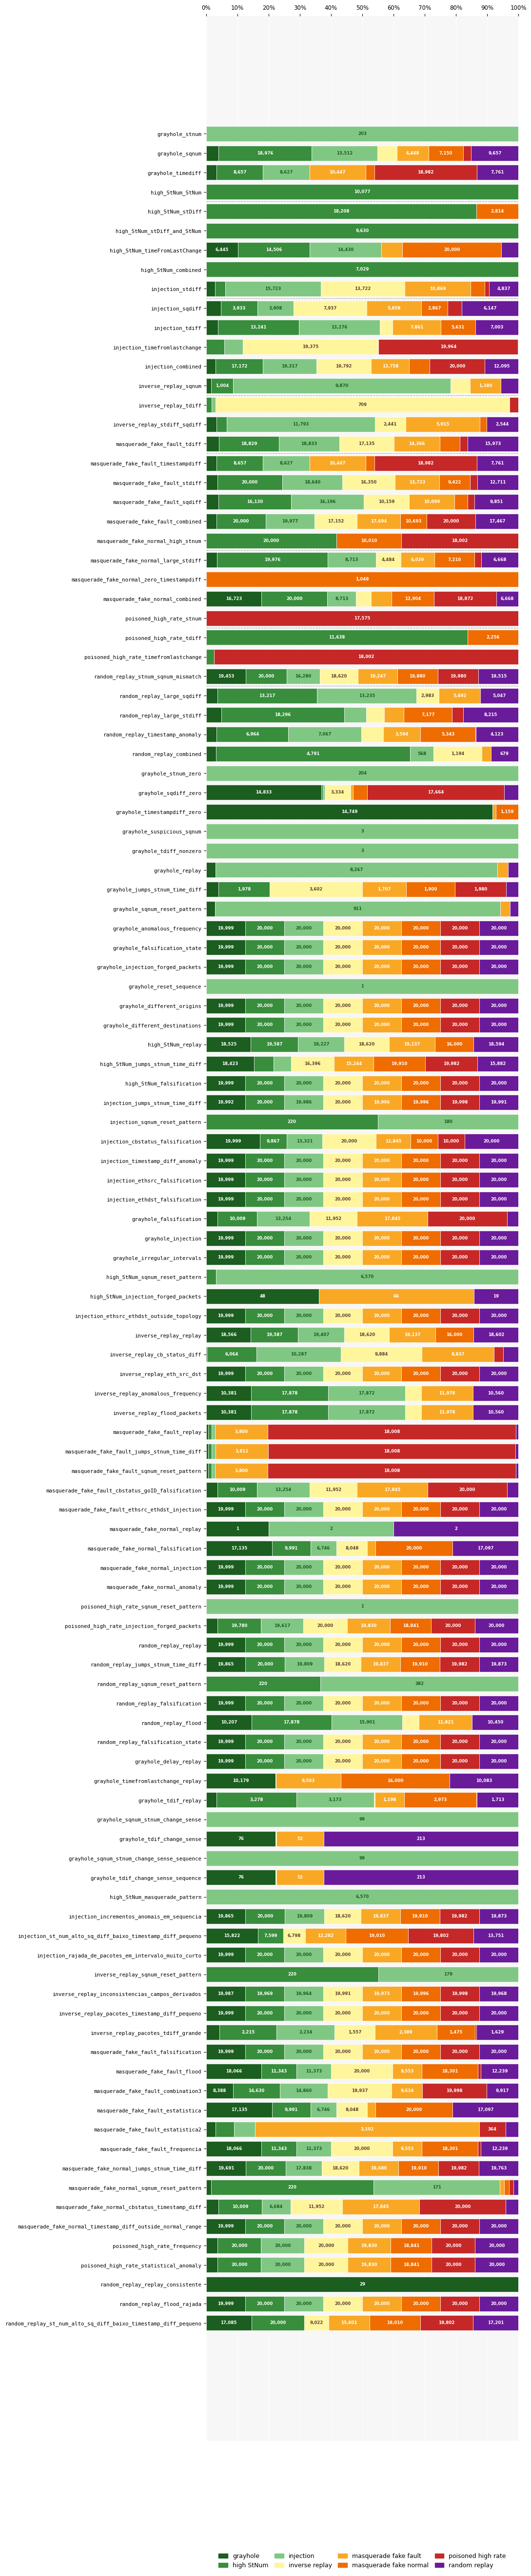

✓ Salvo em: matriz_regras_ataques_plot.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Ajuste o caminho do CSV aqui ────────────────────────────────
CSV_PATH = "matriz_regras_ataques.csv"
OUTPUT   = "matriz_regras_ataques_plot.png"
# ────────────────────────────────────────────────────────────────

# ── Lê direto o CSV já computado pelo script anterior ───────────
df = pd.read_csv(CSV_PATH, index_col="Regra")
df = df.drop(columns=["normal"], errors="ignore")
df = df[df.sum(axis=1) > 0]
df_pct = df.div(df.sum(axis=1), axis=0) * 100

# ── Paleta: cores fixas para classes conhecidas,
#    fallback automático para qualquer classe nova ───────────────
KNOWN_COLORS = {
    "grayhole":               "#1b5e20",
    "high_StNum":             "#388e3c",
    "injection":              "#81c784",
    "inverse_replay":         "#fff59d",
    "masquerade_fake_fault":  "#f9a825",
    "masquerade_fake_normal": "#ef6c00",
    "poisoned_high_rate":     "#c62828",
    "random_replay":          "#6a1b9a",
}

KNOWN_TEXT = {
    "grayhole":               "white",
    "high_StNum":             "white",
    "injection":              "#1b5e20",
    "inverse_replay":         "#5d4037",
    "masquerade_fake_fault":  "white",
    "masquerade_fake_normal": "white",
    "poisoned_high_rate":     "white",
    "random_replay":          "white",
}

# Paleta de fallback para classes não mapeadas
_FALLBACK_PALETTE = plt.cm.tab20.colors  # 20 cores distintas
attacks = df_pct.columns.tolist()

def _luminance(hex_color):
    """Retorna luminância relativa (0–1) de uma cor hex."""
    c = hex_color.lstrip("#")
    r, g, b = (int(c[i:i+2], 16) / 255 for i in (0, 2, 4))
    def lin(v): return v / 12.92 if v <= 0.04045 else ((v + 0.055) / 1.055) ** 2.4
    return 0.2126 * lin(r) + 0.7152 * lin(g) + 0.0722 * lin(b)

attack_colors = {}
text_color_map = {}
_fallback_idx = 0
for atk in attacks:
    if atk in KNOWN_COLORS:
        attack_colors[atk] = KNOWN_COLORS[atk]
        text_color_map[atk] = KNOWN_TEXT[atk]
    else:
        color = "#{:02x}{:02x}{:02x}".format(
            *[int(c * 255) for c in _FALLBACK_PALETTE[_fallback_idx % 20][:3]]
        )
        attack_colors[atk] = color
        text_color_map[atk] = "white" if _luminance(color) < 0.4 else "#333333"
        _fallback_idx += 1

# ── Plot ─────────────────────────────────────────────────────────
rules      = df_pct.index.tolist()
n_rules    = len(rules)
fig_height = max(10, n_rules * 0.48)

fig, ax = plt.subplots(figsize=(11, fig_height))
rule_labels = [r.replace("rule_", "") for r in rules]

lefts = np.zeros(n_rules)
for attack in attacks:
    color    = attack_colors[attack]
    txt_col  = text_color_map[attack]
    pct_vals = df_pct[attack].values
    abs_vals = df[attack].values
    ax.barh(
        range(n_rules), pct_vals, left=lefts,
        color=color, edgecolor="white", linewidth=0.5, height=0.78
    )
    for j, (pct, abv, l) in enumerate(zip(pct_vals, abs_vals, lefts)):
        if pct >= 7:
            ax.text(
                l + pct / 2, j, f"{int(abv):,}",
                ha="center", va="center",
                fontsize=6.2, color=txt_col, fontweight="bold"
            )
    lefts += pct_vals

ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 10)], fontsize=8.5)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", bottom=False, top=True, labelbottom=False, labeltop=True)

ax.set_yticks(range(n_rules))
ax.set_yticklabels(rule_labels, fontsize=7.8, fontfamily="monospace")
ax.invert_yaxis()

# Separadores: calculados automaticamente a cada grupo de regras
separators = [3.5, 8.5, 13.5, 16.5, 21.5, 25.5, 28.5]
for s in separators:
    if s < n_rules:
        ax.axhline(s, color="#aaaaaa", linewidth=0.8, linestyle="--", zorder=2)

ax.set_axisbelow(True)
ax.xaxis.grid(True, color="white", linewidth=0.7)
ax.set_facecolor("#f7f7f7")
for spine in ax.spines.values():
    spine.set_visible(False)

patches = [
    mpatches.Patch(color=attack_colors[a], label=a.replace("_", " "))
    for a in attacks
]
ax.legend(
    handles=patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.055),
    ncol=4, fontsize=9,
    frameon=False,
    handlelength=1.5,
    columnspacing=1.0
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT, dpi=180, bbox_inches="tight")
plt.show()
print(f"✓ Salvo em: {OUTPUT}")

---
## 8. Considerações Finais

Este trabalho apresentou um pipeline orientado por LLM que automatiza a geração de regras de detecção para IDS baseados em especificação em subestações IEC 61850.

### Contribuições principais

- **Pipeline plug-and-play** end-to-end: do dataset rotulado às regras executáveis
- **Redução da dependência de especialistas** para criação manual de regras
- **Baixo overhead operacional**: regras Python leves adequadas a ambientes em tempo real
- **Reprodutibilidade**: parâmetros configuráveis e artefatos rastreáveis

### Limitações e trabalhos futuros

- Validação em hardware real de subestação (não apenas simulado)
- Avaliação com mais classes de ataque do dataset ERENO
- Comparação com abordagens de ML supervisionado
- Adaptação automática a novos padrões de ataque via atualização incremental

> **Repositório:** https://github.com/sequincozes/CounselorNode

---
## 9. Referências

- **Commission, I. E.** (2003). Communication networks and systems in substations - Part 8-1: SCSM. IET.

- **Hong, J. and Liu, C.** (2019). Intelligent electronic devices with collaborative intrusion detection systems. *IEEE Transactions on Smart Grid*, 10(1):271–281.

- **Hong, J., Liu, C., and Govindarasu, M.** (2014a). Detection of Cyber Intrusions Using Network-Based Multicast Messages for Substation Automation. *ISGT*, IEEE.

- **Hong, J., Liu, C., and Govindarasu, M.** (2014b). Integrated anomaly detection for cyber security of the substations. *IEEE Transactions on Smart Grid*, 5(4):1643–1653.

- **Kwon, Y. et al.** (2015). A behavior-based intrusion detection technique for smart grid infrastructure. *IEEE Eindhoven PowerTech*.

- **Malik, H., Alotaibi, M. A., and Almutairi, A.** (2022). Cyberattacks identification in IEC 61850 based substation using proximal SVM. *Journal of Intelligent & Fuzzy Systems*, 42(2):1213–1222.

- **Quincozes, S. E. et al.** (2021). A survey on intrusion detection and prevention systems in digital substations. *Computer Networks*, 184:107679.

- **Quincozes, S. E. et al.** (2022). ERENO: An Extensible Tool for Generating Realistic IEC–61850 Intrusion Detection Datasets. PhD thesis, UFF.

- **Yang, Y. et al.** (2016a). Intrusion detection system for IEC 61850 based smart substations. *IEEE PESGM*.

- **Yang, Y. et al.** (2016b). Multidimensional intrusion detection system for IEC 61850-based SCADA networks. *IEEE Transactions on Power Delivery*, 32(2):1068–1078.